# SWOT alias-decomposition run (Dask)

Processes SWOT L2 LR Unsmoothed file(s) with `swot_analysis.swot_alias_wrapper.process_one_file`, parallelized over a Dask `LocalCluster`, and pools the per-swath segments into `all_segments`.

In [1]:
import traceback
import glob
import os
from pathlib import Path

from dask.distributed import Client, LocalCluster, as_completed

from swot_analysis.swot_alias_wrapper import process_one_file


# ── Files ──────────────────────────────────────────────────────────────────
#DATA_DIR        = '/Volumes/PortableSSD/'
DATA_DIR    = '/work/uo0122/u241387/SWOT_SSH/SSH_Unsmoothed/'

#EXPERT_FILE     = 'SWOT_L2_LR_SSH_Expert_0524/SWOT_L2_LR_SSH_Expert_016_074_20240531T192537_20240531T201622_PGD0_01.nc'
DATA_SUBDIRS = ['SWOT_L2_LR_SSH_Unsmoothed_0124/']
#'SWOT_L2_LR_SSH_Unsmoothed_016_074_20240531T192538_20240531T201625_PGD0_01.nc'
FILE_PATTERN = 'SWOT_L2_LR_SSH_Unsmoothed_*.nc'

# Files to process. Add more paths here (or glob a directory) to batch-process.
filepaths=[]
for subdir in DATA_SUBDIRS[:1]:
    #year, month = parse_year_month(subdir, overrides=DATA_SUBDIR_OVERRIDES)
    subdir_files = sorted(glob.glob(os.path.join(DATA_DIR, subdir, FILE_PATTERN)))[:]
    #print(f'{subdir:30s} -> {len(subdir_files):4d} files  (year={year}, month={month:02d})')
    filepaths.extend(subdir_files)
    #file_year_month.extend([(year, month)] * len(subdir_files))

print(f'\n{len(filepaths)} Unsmoothed granule files found across {len(DATA_SUBDIRS)} sub-directories.')


OUTPUT_DIR = None#Path("./swot_alias_results")
#OUTPUT_DIR = Path("/work/uo0122/u241387/SWOT_SSH/swot_alias_results")
#OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_WORKERS = 1  # max(1, (os.cpu_count() or 2) - 1)
THREADS_PER_WORKER = 1
MEMORY_LIMIT = "5GB"

SEGMENT_LENGTH_KM = 250.0
OVERLAP = 0.0

MAX_NAN_FRACTION = 0.15
MAX_GAP_FRACTION = 0.1
N_TAPS = 17
MAX_GAP_KM = 75.0

DX1_NATIVE_KM = 0.25
DX2_NATIVE_KM = 0.25

DX1_EXPERT_KM = 2.0
DX2_EXPERT_KM = 2.0

HRET = False
SSH_VAR = "ssha_karin_2"

FULL_DIRECT = True
#print(f"{len(filepaths)} files")
print(f"{N_WORKERS} workers")



865 Unsmoothed granule files found across 1 sub-directories.
1 workers


## Start the Dask cluster

Each worker is a separate process (matches the old `ProcessPoolExecutor` behavior). The dashboard link printed below is handy for watching progress/memory.

In [2]:
import dask
dask.config.config.get('distributed').get('dashboard').update(
    {'link': '{JUPYTERHUB_SERVICE_PREFIX}/proxy/{port}/status'}
)

cluster = LocalCluster(
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    dashboard_address=':8787',
)
client = Client(cluster)
print(f"Dashboard: {client.dashboard_link}")
client

Dashboard: /user/u241387/levante-spawner-preset//proxy/8787/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/u241387/levante-spawner-preset//proxy/8787/status,
Dashboard: /user/u241387/levante-spawner-preset//proxy/8787/status,Workers: 1
Total threads: 1,Total memory: 4.66 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35565,Workers: 0
Dashboard: /user/u241387/levante-spawner-preset//proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37885,Total threads: 1
Dashboard: /user/u241387/levante-spawner-preset//proxy/34117/status,Memory: 4.66 GiB
Nanny: tcp://127.0.0.1:35147,


2026-08-26 11:19:59,934 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='jupyterhub.dkrz.de', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/home/u/u241387/.conda/envs/swot_env/lib/python3.11/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/u/u241387/.conda/envs/swot_env/lib/python3.11/site-packages/tornado/web.py", line 3409, in wrapper
    return method(self, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/u/u241387/.conda/envs/swot_env/lib/python3.11/site-packages/bokeh/server/views/ws.py", line 157, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.pr

## Process each file

Each worker loads one Unsmoothed file, computes the direct/aliased/total spectra for both swaths, and writes a `<stem>_alias.pkl` next to `OUTPUT_DIR`.

In [3]:
def run_one_file(filepath):
    filepath = Path(filepath)
    if OUTPUT_DIR is not None:
        output_file = OUTPUT_DIR / f"{filepath.stem}_alias.pkl"
    else:
        output_file=None
    try:
        result = process_one_file(
            filepath,
            output_file,

            segment_length_km=SEGMENT_LENGTH_KM,
            overlap=OVERLAP,

            max_nan_fraction=MAX_NAN_FRACTION,
            max_gap_fraction=MAX_GAP_FRACTION,
            n_taps=N_TAPS,

            dx1_native_km=DX1_NATIVE_KM,
            dx2_native_km=DX2_NATIVE_KM,
            dx1_expert_km=DX1_EXPERT_KM,
            dx2_expert_km=DX2_EXPERT_KM,

            hret=HRET,
            ssh_var=SSH_VAR,
            full_direct=FULL_DIRECT,
        )

        return {
            "file": str(filepath),
            "result": result,
            "error": None,
        }

    except Exception:
        return {
            "file": str(filepath),
            "result": None,
            "error": traceback.format_exc(),
        }

def run_one_file(filepath):
    #filepath = Path(filepath)
    if OUTPUT_DIR is not None:
        output_file = OUTPUT_DIR / f"{filepath.stem}_alias.pkl"
    else:
        output_file = None
    try:
        result = process_one_file(
            filepath,
            output_file,
            segment_length_km=SEGMENT_LENGTH_KM,
            overlap=OVERLAP,
            max_nan_fraction=MAX_NAN_FRACTION,
            max_gap_fraction=MAX_GAP_FRACTION,
            max_gap_km=MAX_GAP_KM,          # <-- new
            n_taps=N_TAPS,
            dx1_native_km=DX1_NATIVE_KM,
            dx2_native_km=DX2_NATIVE_KM,
            dx1_expert_km=DX1_EXPERT_KM,
            dx2_expert_km=DX2_EXPERT_KM,
            hret=HRET,
            ssh_var=SSH_VAR,
            full_direct=FULL_DIRECT,
           # return_counts=True
        )
        if FULL_DIRECT:
            return {
            "file": str(filepath),
            "result": result[0],
            "result_full": result[1],
            "error": None,
            }
        else:
            return {
                "file": str(filepath),
                "result": result,
                "error": None,
            }
    except Exception:
        return {
            "file": str(filepath),
            "result": None,
            "error": traceback.format_exc(),
        }


In [27]:
results = []
results_full = []
#nseg    = []

futures = client.map(run_one_file, [str(f) for f in filepaths[-50:]])

for i, future in enumerate(as_completed(futures), start=1):

    result = future.result()
    
    #results_full.append(result_full)

    filepath = Path(result["file"])

    if result["error"] is None:
        results.append(result)
        #print(f"[{i}/{len(filepaths)}] OK   {filepath.name}")
    else:
        #print(f"[{i}/{len(filepath)}] FAIL {filepath.name}")
        print(result["error"])
        
    

Traceback (most recent call last):
  File "/tmp/ipykernel_3367713/1972531768.py", line 49, in run_one_file
  File "/home/u/u241387/SWOT_UHH/swot_analysis/swot_alias_wrapper.py", line 164, in process_one_file
    by_swath, by_swath_full = compute_alias_pass_spectra(
                              ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/u/u241387/SWOT_UHH/swot_analysis/swot_alias_spectra.py", line 1403, in compute_alias_pass_spectra
    results[swath], results_full[swath] = compute_alias_swath_spectra(
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: cannot unpack non-iterable AliasPassSpectrumResult object

Traceback (most recent call last):
  File "/tmp/ipykernel_3367713/1972531768.py", line 49, in run_one_file
  File "/home/u/u241387/SWOT_UHH/swot_analysis/swot_alias_wrapper.py", line 164, in process_one_file
    by_swath, by_swath_full = compute_alias_pass_spectra(
                              ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/u/u241387/SWOT_UHH/swot_analysis/swot_alias_s

## Pool segments across files

Each successful `result["result"]` is a dict with `"left"`/`"right"` keys, each a list of `AliasSegmentSpectrum` objects.

In [28]:
all_segments = {
    "left": [],
    "right": [],
}

for entry in results:
    if entry["error"] is not None:
        continue

    result = entry["result"]

    for swath in ("left", "right"):
        all_segments[swath].extend(result[swath])

print(f'left : {len(all_segments["left"])} segments')
print(f'right: {len(all_segments["right"])} segments')

if FULL_DIRECT:
    all_segments_full = {
    "left": [],
    "right": [],
    }
    for entry in results:
        result = entry["result_full"]

        for swath in ("left", "right"):
            all_segments_full[swath].extend(result[swath])

print(f'left (full) : {len(all_segments_full["left"])} segments')
print(f'right (full): {len(all_segments_full["right"])} segments')

left : 2076 segments
right: 2050 segments
left (full) : 2076 segments
right (full): 2050 segments


## Pack into an xarray Dataset

Every segment (both swaths, every file) has the same wavenumber-axis length, so they always stack cleanly -- no interpolation or padding needed.

In [29]:
def parse_year_month(subdir_name, overrides=None):
    if overrides and subdir_name in overrides:
        return overrides[subdir_name]
    name = subdir_name.rstrip("/").rstrip("\\")
    match = re.search(r"(\d{2})(\d{2})$", name)
    if not match:
        raise ValueError(
            f"Could not infer year/month from subdirectory name '{subdir_name}'. "
            f"Add an explicit entry to DATA_SUBDIR_OVERRIDES instead."
        )
    mm, yy = match.groups()
    month = int(mm)
    year = 2000 + int(yy)
    if not (1 <= month <= 12):
        raise ValueError(f"Parsed invalid month={month} from '{subdir_name}'.")
    return year, month

In [30]:
from swot_analysis.swot_alias_spectra import segments_to_dataset, full_segments_to_dataset
import re
SAVE_DIR = "/work/uo0122/u241387/SWOT_SSH/"
year, month = parse_year_month(DATA_SUBDIRS[0])
out_path = os.path.join(SAVE_DIR, f"swot_segments_{year}{month:02d}.nc")
#monthly_segment_files.append(out_path)
ds_segments = segments_to_dataset(all_segments["left"] + all_segments["right"])
ds_segments_full = full_segments_to_dataset(all_segments_full["left"] + all_segments_full["right"])

#ds_month = segments_to_dataset(all_segments, wavenumber)
#ds_segments.to_netcdf(out_path, mode="w")

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean
import xarray as xr
def build_box_dataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_seg: int = 5) -> xr.Dataset:

    from collections import defaultdict

    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    direct_all = ds_segments['direct_psd'].values
    aliased_all = ds_segments['aliased_psd'].values
    total_all = ds_segments['total_psd'].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n = [], [], []
    rows_direct, rows_aliased, rows_total = [], [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_direct.append(np.nanmean(direct_all[idxs, :], axis=0))
        rows_aliased.append(np.nanmean(aliased_all[idxs, :], axis=0))
        rows_total.append(np.nanmean(total_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)

    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_seg # * n_max

    direct_stack  = np.stack(rows_direct, axis=0)
    aliased_stack  = np.stack(rows_aliased, axis=0)
    total_stack  = np.stack(rows_total, axis=0)
    lat_center = np.array(rows_lat)
    lon_center = np.array(rows_lon)

    return xr.Dataset(
        data_vars=dict(
            direct_mean_psd=(['box', 'wavenumber'], direct_stack[keep],
                      {'long_name': 'Box-mean SSH(A) direct PSD', 'units': 'm^2 / (cycles/km)'}),
            aliased_mean_psd=(['box', 'wavenumber'], aliased_stack[keep],
                      {'long_name': 'Box-mean SSH(A) aliased PSD', 'units': 'm^2 / (cycles/km)'}),
            total_mean_psd=(['box', 'wavenumber'], total_stack[keep],
                      {'long_name': 'Box-mean SSH(A) total PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
            lat_center=(['box'], lat_center[keep], {'units': 'degrees_north'}),
            lon_center=(['box'], lon_center[keep], {'units': 'degrees_east'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_seg),
    )

def build_box_fulldataset(ds_segments: xr.Dataset,
                      box_deg: float = 2.0,
                      min_sampling_seg: int = 5) -> xr.Dataset:

    from collections import defaultdict

    lat     = ds_segments['lat_mean'].values
    lon     = ds_segments['lon_mean'].values
    lat_idx = np.floor(lat / box_deg).astype(int)
    lon_idx = np.floor(lon / box_deg).astype(int)

    box_to_segs = defaultdict(list)
    for i, key in enumerate(zip(lat_idx, lon_idx)):
        box_to_segs[key].append(i)

    direct_all = ds_segments['direct_psd'].values
    native_all = ds_segments['native_psd'].values
    wavenumber = ds_segments['wavenumber'].values
    rows_lat, rows_lon, rows_n = [], [], []
    rows_direct, rows_aliased, rows_total = [], [], []

    for (li, loi), idxs in sorted(box_to_segs.items()):
        rows_direct.append(np.nanmean(direct_all[idxs, :], axis=0))
        rows_total.append(np.nanmean(native_all[idxs, :], axis=0))
        rows_n.append(len(idxs))
        rows_lat.append((li  + 0.5) * box_deg)
        rows_lon.append((loi + 0.5) * box_deg)

    n_segments = np.array(rows_n)
    n_max      = n_segments.max()
    keep       = n_segments >= min_sampling_seg # * n_max

    direct_stack  = np.stack(rows_direct, axis=0)
    total_stack  = np.stack(rows_total, axis=0)
    lat_center = np.array(rows_lat)
    lon_center = np.array(rows_lon)

    return xr.Dataset(
        data_vars=dict(
            direct_mean_psd=(['box', 'wavenumber'], direct_stack[keep],
                      {'long_name': 'Box-mean SSH(A) direct PSD', 'units': 'm^2 / (cycles/km)'}),
            native_mean_psd=(['box', 'wavenumber'], total_stack[keep],
                      {'long_name': 'Box-mean SSH(A) total PSD', 'units': 'm^2 / (cycles/km)'}),
            n_segments=(['box'], n_segments[keep]),
            sampling_fraction=(['box'], n_segments[keep] / n_max),
            lat_center=(['box'], lat_center[keep], {'units': 'degrees_north'}),
            lon_center=(['box'], lon_center[keep], {'units': 'degrees_east'}),
        ),
        coords=dict(
            wavenumber=('wavenumber', wavenumber, {'units': 'cycles/km'}),
            box=('box', np.arange(keep.sum())),
        ),
        attrs=dict(box_size_deg=box_deg,
                   min_sampling_fraction=min_sampling_seg),
    )

In [32]:
BOX_DEG = 2.0
ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG,min_sampling_seg=1)
ds_boxes_full = build_box_fulldataset(ds_segments_full, box_deg=BOX_DEG,min_sampling_seg=1)
#ds_boxes = build_box_dataset(ds_segments, box_deg=BOX_DEG)
print(f'Box dataset: {ds_boxes.sizes["box"]} boxes with at least 1 segment')
ds_boxes

Box dataset: 2731 boxes with at least 1 segment


<xarray.Dataset> Size: 4MB
Dimensions:            (box: 2731, wavenumber: 63)
Coordinates:
  * box                (box) int64 22kB 0 1 2 3 4 5 ... 2726 2727 2728 2729 2730
  * wavenumber         (wavenumber) float64 504B 0.0 0.004 0.008 ... 0.244 0.248
Data variables:
    direct_mean_psd    (box, wavenumber) float64 1MB 0.002308 ... 1.84e-05
    aliased_mean_psd   (box, wavenumber) float64 1MB 0.0007817 ... 6.972e-05
    total_mean_psd     (box, wavenumber) float64 1MB 0.00309 ... 8.812e-05
    n_segments         (box) int64 22kB 1 1 1 2 1 2 2 1 1 ... 1 1 1 2 1 1 1 1 1
    sampling_fraction  (box) float64 22kB 0.25 0.25 0.25 0.5 ... 0.25 0.25 0.25
    lat_center         (box) float64 22kB -77.0 -77.0 -77.0 ... 77.0 77.0 77.0
    lon_center         (box) float64 22kB 169.0 173.0 175.0 ... 57.0 59.0 65.0
Attributes:
    box_size_deg:           2.0
    min_sampling_fraction:  1

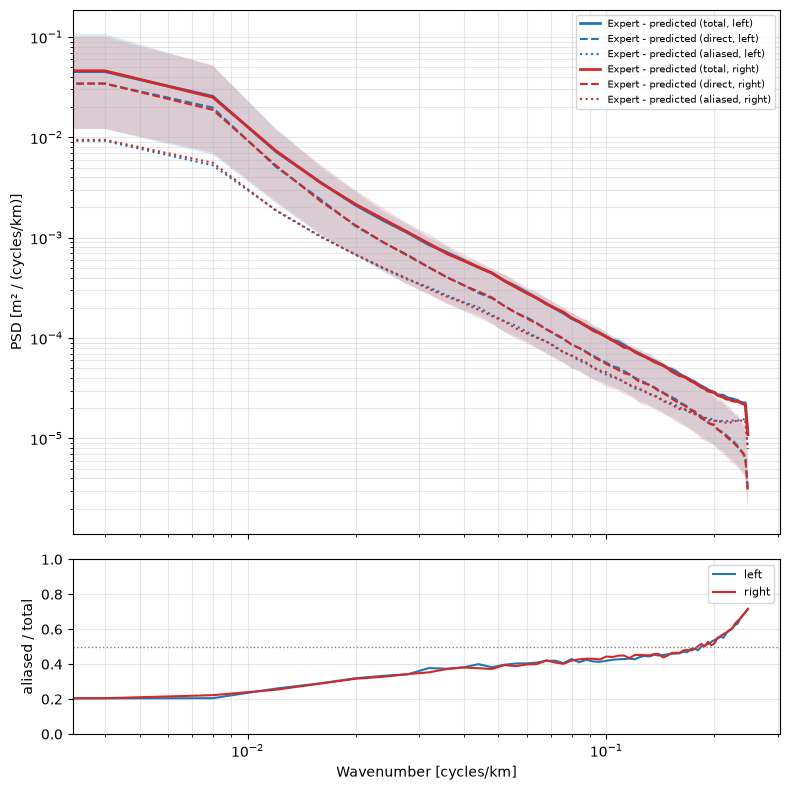

In [33]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))

colors = {'left': 'C0', 'right': 'C3'}

for swath, c in colors.items():
    recs = ds_segments.where(ds_segments.swath==swath,drop=True)
    if not recs:
        continue
    k = recs['wavenumber'].values
    direct_stack = recs['direct_psd'].values
    aliased_stack = recs['aliased_psd'].values
    total_stack = direct_stack + aliased_stack
    
    direct_median = np.nanmedian(direct_stack, axis=0)
    direct_lo, direct_hi = np.nanpercentile(direct_stack, [25, 75], axis=0)
    aliased_median = np.nanmedian(aliased_stack, axis=0)
    aliased_lo, aliased_hi = np.nanpercentile(aliased_stack, [25, 75], axis=0)
    total_median = np.nanmedian(total_stack, axis=0)
    
    ax = axs[0]
    ax.fill_between(k, direct_lo, direct_hi, color=c, alpha=0.15, lw=0)
    ax.loglog(k, total_median, c=c, lw=2, label=f'Expert - predicted (total, {swath})')
    ax.loglog(k, direct_median, c=c, lw=1.5, ls='--', label=f'Expert - predicted (direct, {swath})')
    ax.loglog(k, aliased_median, c=c, lw=1.5, ls=':', label=f'Expert - predicted (aliased, {swath})')
    axs[1].semilogx(k, aliased_median / total_median, c=c, lw=1.5, label=swath)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
#axs[0].set_title(f'Patch-matched validation ({sum(len(v) for v in patch_match_results.values())} '
#                  f'matched patches, this file)')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)

axs[1].axhline(0.5, c='0.5', ls=':', lw=1)
axs[1].set_ylabel('aliased / total')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].legend(fontsize=8)
axs[1].set_ylim(0.,1.0)
fig.tight_layout()

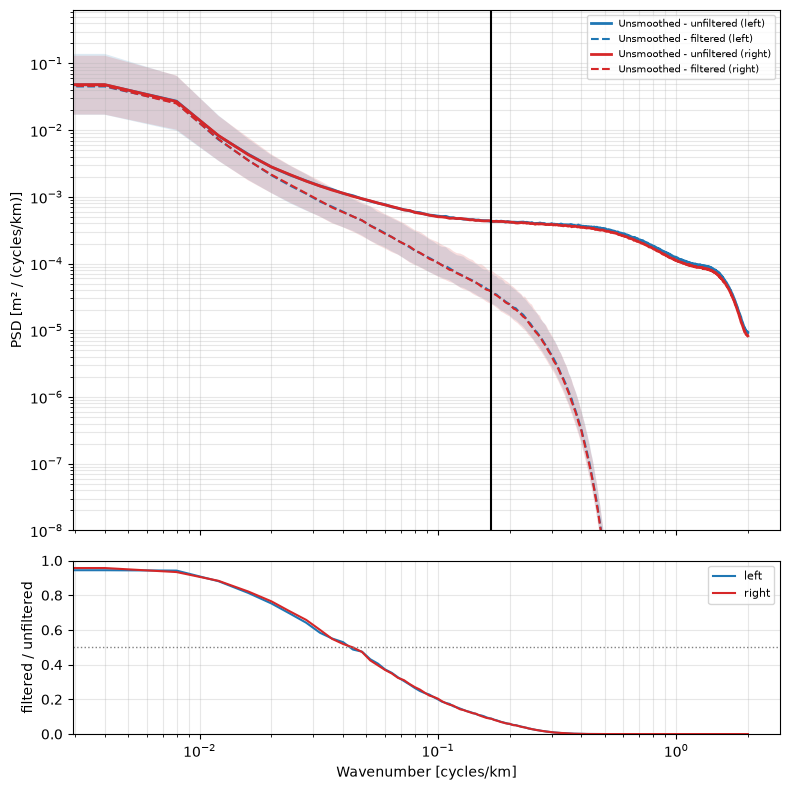

In [34]:
fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))

colors = {'left': 'C0', 'right': 'C3'}

for swath, c in colors.items():
    recs = ds_segments_full.where(ds_segments_full.swath==swath,drop=True)
    if not recs:
        continue
    k = recs['wavenumber'].values
    direct_stack = recs['direct_psd'].values
    total_stack = recs['native_psd'].values
    
    direct_median = np.nanmedian(direct_stack, axis=0)
    direct_lo, direct_hi = np.nanpercentile(direct_stack, [25, 75], axis=0)
    total_median = np.nanmedian(total_stack, axis=0)
    
    ax = axs[0]
    ax.fill_between(k, direct_lo, direct_hi, color=c, alpha=0.15, lw=0)
    ax.loglog(k, total_median, c=c, lw=2, label=f'Unsmoothed - unfiltered ({swath})')
    ax.loglog(k, direct_median, c=c, lw=1.5, ls='--', label=f'Unsmoothed - filtered ({swath})')
    axs[1].semilogx(k, direct_median / total_median, c=c, lw=1.5, label=swath)

axs[0].set_ylabel('PSD [m² / (cycles/km)]')
#axs[0].set_title(f'Patch-matched validation ({sum(len(v) for v in patch_match_results.values())} '
#                  f'matched patches, this file)')
axs[0].grid(True, which='both', alpha=0.3)
axs[0].legend(fontsize=7)
axs[0].set_ylim(1e-8,None)
axs[0].axvline(1/6,c='k')

axs[1].axhline(0.5, c='0.5', ls=':', lw=1)
axs[1].set_ylabel('filtered / unfiltered')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].legend(fontsize=8)
axs[1].set_ylim(0.,1.0)
fig.tight_layout()

In [35]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
import cartopy
cartopy.config['data_dir'] = '/work/uo0122/u241387/cartopy_data'

def plot_box(var : np.array, lon : np.array, lat : np.array,
             projection : ccrs = ccrs.Robinson(), cmap : str="viridis", 
             min_size : int=20, max_size : int=300, figsize : tuple=(14, 7),
             title : str = "Number of observations per box", label : str = "Number of observations",
            vmin : float = None, vmax : float = None, norm=None
            ):

    mask = np.isfinite(var)
    lon = lon[mask]
    lat = lat[mask]
    var = var[mask]

    fig = plt.figure(figsize=figsize)
    ax = plt.axes(projection=projection)
    ax.set_global()
    ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
    ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
    ax.add_feature(cfeature.BORDERS,linewidth=0.3)
    gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
    gl.top_labels = False
    gl.right_labels = False

    gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
    gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

    gl.xlabel_style = {"size": 10,"color": "black",}

    gl.ylabel_style = {"size": 10,"color": "black",}
    
    if norm is not None:
        sc = ax.scatter(lon,lat,s=45,c=var,
                    cmap=cmap,edgecolors=None,linewidths=0.25,
                    transform=ccrs.PlateCarree(),norm = norm)
    else:
        if vmin is None:
            vmin,vmax=np.nanmin(var),np.nanmax(var)
            
        sc = ax.scatter(lon,lat,s=45,c=var,
                        cmap=cmap,edgecolors=None,linewidths=0.25,
                        transform=ccrs.PlateCarree(),vmin = vmin, vmax = vmax)

    #cb = plt.colorbar(sc,ax=ax)
    #cb.set_label(label)
    ax.set_title(title)
    
    return fig, ax

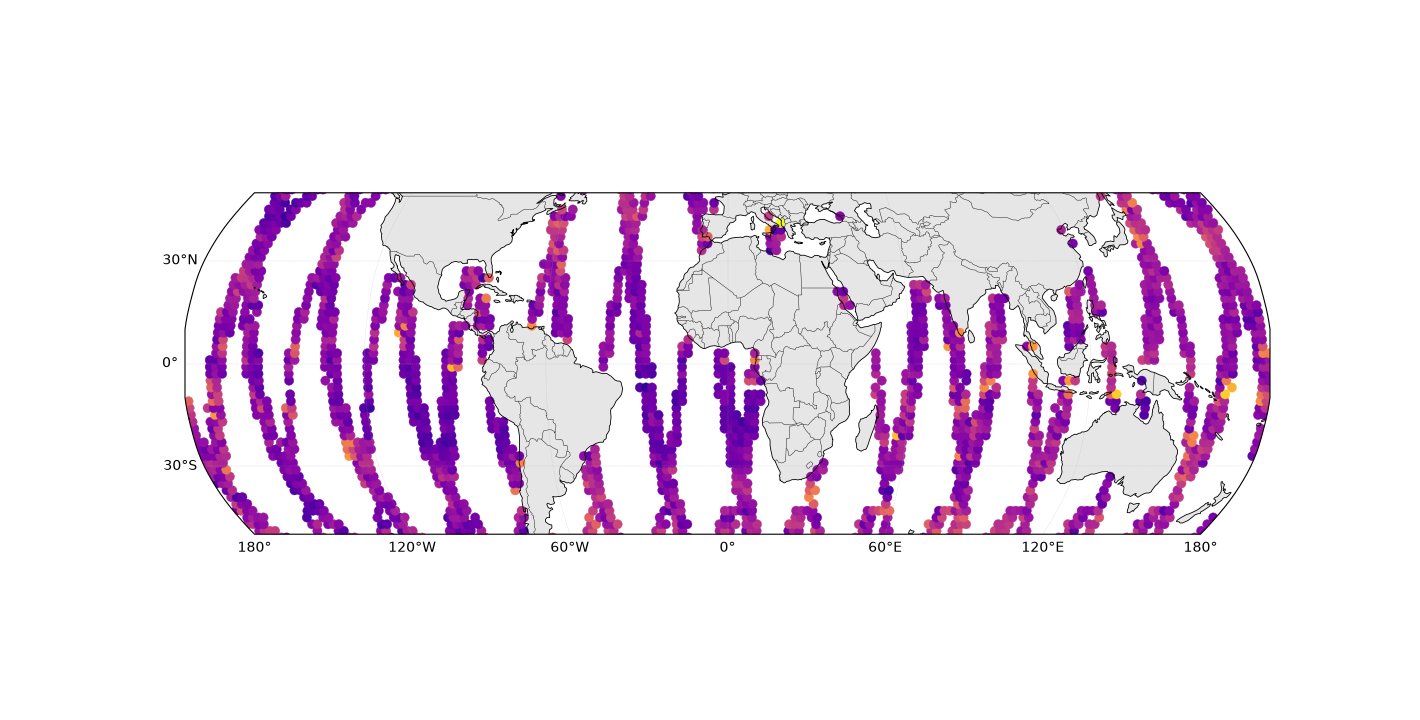

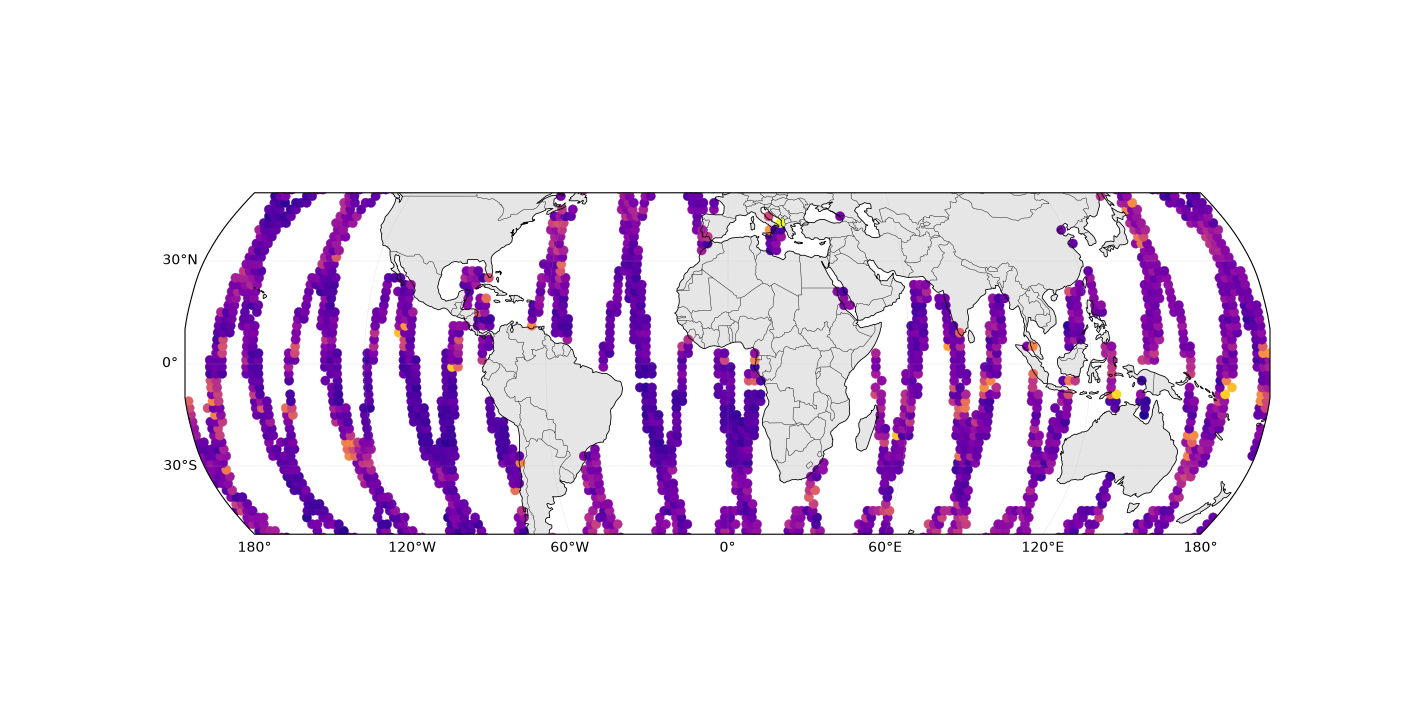

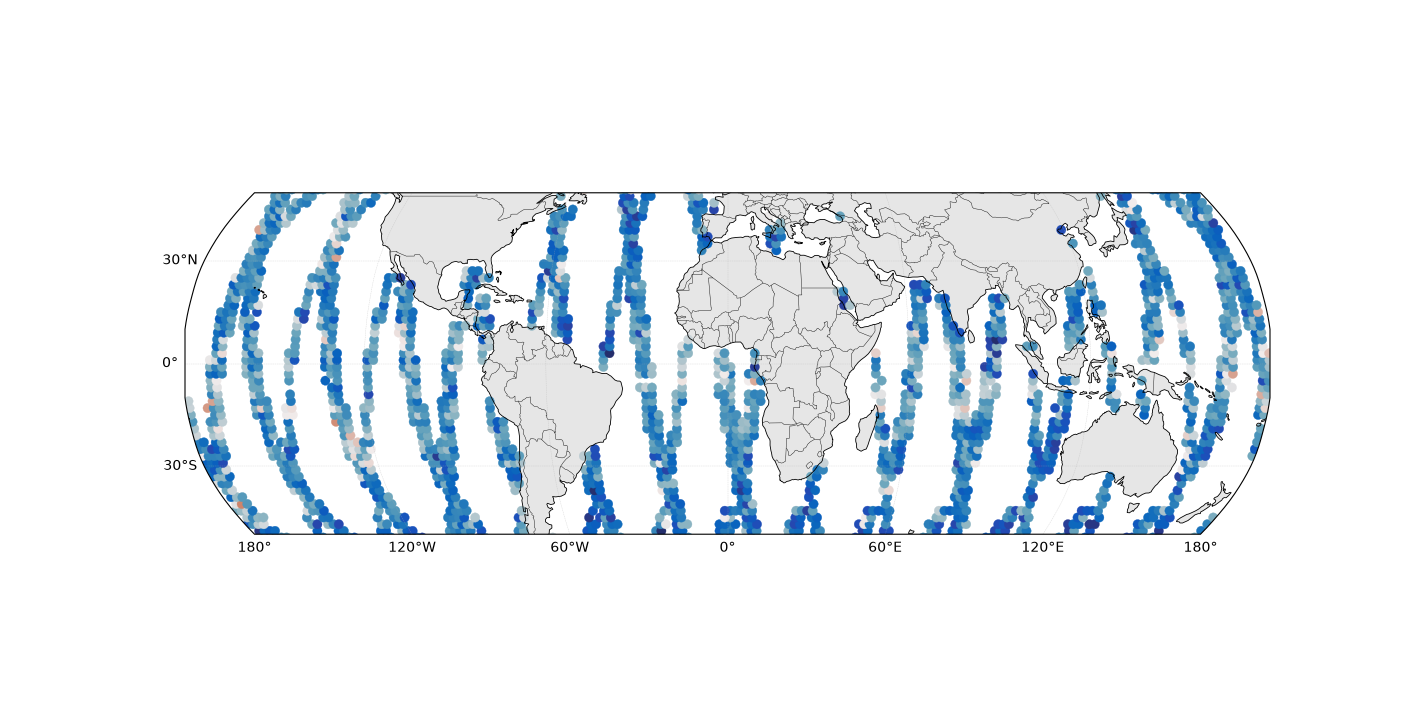

In [36]:
LON_MIN, LON_MAX = 0., 360.
LAT_MIN, LAT_MAX = -50, 50
fig, ax = plot_box(np.log10(ds_boxes["direct_mean_psd"].integrate('wavenumber').values),
                   ds_boxes["lon_center"].values,
                   ds_boxes["lat_center"].values,
                   #projection=ccrs.EqualEarth(),
                   cmap="plasma", title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

fig, ax = plot_box(np.log10(ds_boxes["aliased_mean_psd"].integrate('wavenumber').values),
                   ds_boxes["lon_center"].values,
                   ds_boxes["lat_center"].values,
                   #projection=ccrs.EqualEarth(),
                   cmap="plasma", title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ")
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

fig, ax = plot_box((ds_boxes["aliased_mean_psd"].integrate('wavenumber').values / ds_boxes["total_mean_psd"].integrate('wavenumber').values),
                   ds_boxes["lon_center"].values,
                   ds_boxes["lat_center"].values,
                   #projection=ccrs.EqualEarth(),
                   cmap=cmocean.cm.balance, title=f"Number of segments per {BOX_DEG:.1f}° x {BOX_DEG:.1f}° box ",
                  vmin=0,vmax=1.0)
ax.set_extent([LON_MIN-180,LON_MAX-180,LAT_MIN,LAT_MAX], crs=ccrs.PlateCarree())
plt.show()

(0.0, 1.0)

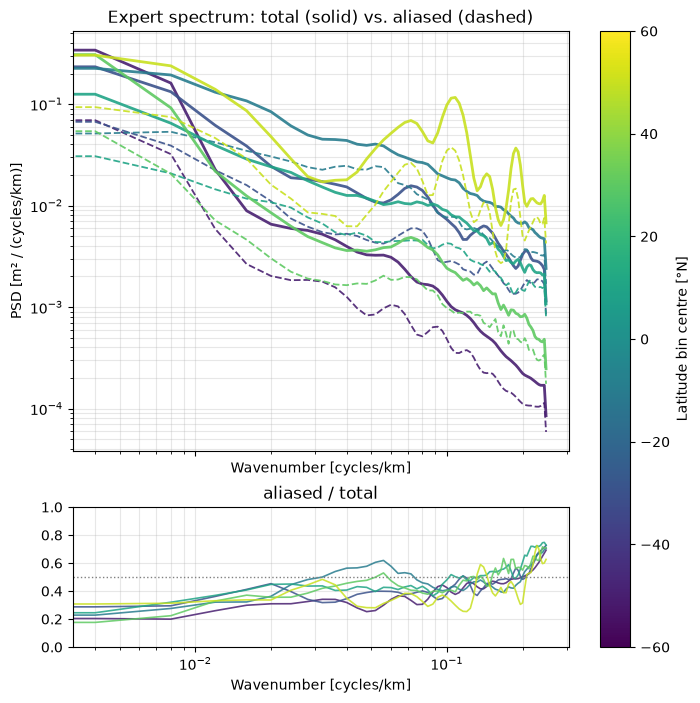

In [37]:
LAT_BIN_EDGES = np.arange(-60, 61, 20)  # adjust to the pass's latitude range

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True,
                         gridspec_kw=dict(height_ratios=[3, 1]))

norm = plt.Normalize(vmin=np.min(LAT_BIN_EDGES), vmax=np.max(LAT_BIN_EDGES))
cmap = plt.get_cmap("viridis")

for lo, hi in zip(LAT_BIN_EDGES[:-1], LAT_BIN_EDGES[1:]):
    #recs = [ds_segments.where(ds_segments.swath==swath,drop=True) for swath in ('left', 'right')]
    recs = ds_segments.where((ds_segments.lat_mean<=hi) & (ds_segments.lat_mean>=lo),drop=True)
    if not recs:
        continue
    k = recs['wavenumber']
    direct_stack = recs['direct_psd'].values
    aliased_stack = recs['aliased_psd'].values
    pred_stack = direct_stack + aliased_stack
    #meas_mean = np.nanmean([r['psd_meas'] for r in recs], axis=0)
    pred_mean = np.nanmean(pred_stack, axis=0)
    aliased_mean = np.nanmean(aliased_stack, axis=0)
    color = cmap(norm((lo + hi) / 2))
    axs[0].loglog(k, pred_mean, color=color, lw=2, alpha=0.9)
    axs[0].loglog(k, aliased_mean, color=color, lw=1.3, ls='--', alpha=0.9)
    axs[1].semilogx(k, aliased_mean / pred_mean, color=color, lw=1.2, alpha=0.85)
    
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=axs, label='Latitude bin centre [°N]')

axs[0].set_title('Expert spectrum: total (solid) vs. aliased (dashed)')
axs[0].set_xlabel('Wavenumber [cycles/km]')
axs[0].set_ylabel('PSD [m² / (cycles/km)]')
axs[0].grid(True, which='both', alpha=0.3)

axs[1].axhline(0.5, c='0.5', ls=':', lw=1)
axs[1].set_title('aliased / total')
axs[1].set_xlabel('Wavenumber [cycles/km]')
axs[1].grid(True, which='both', alpha=0.3)
axs[1].set_ylim(0,1)

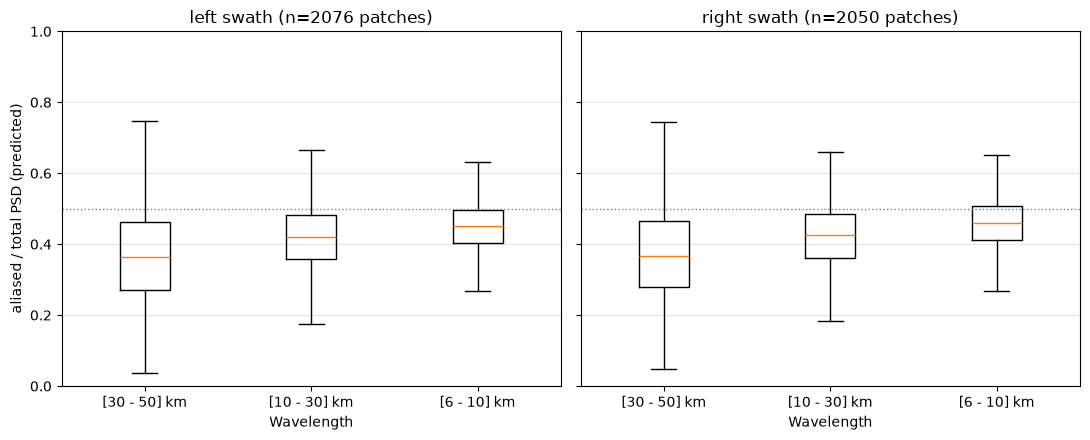

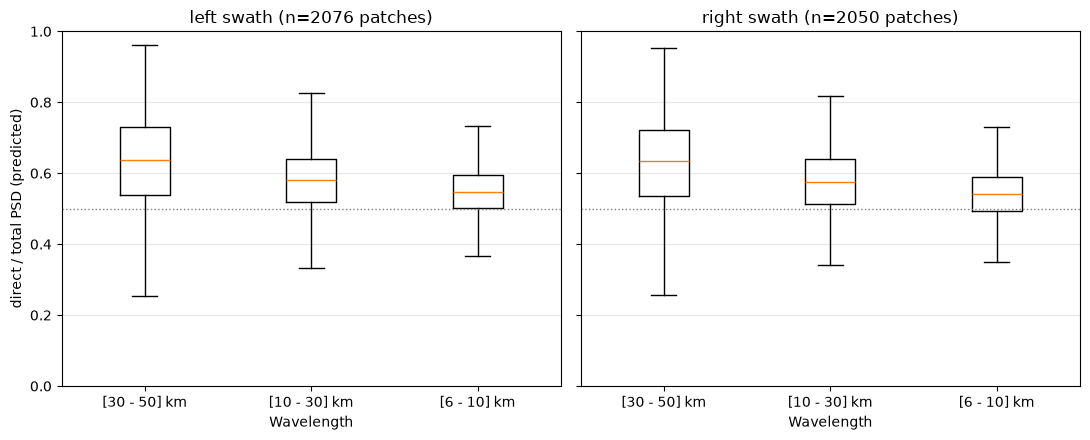

In [38]:
K_MIN = [1/50, 1/30, 1/10]
K_MAX = [1/30, 1/10, 1/6]

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, swath in zip(axs, ('left', 'right')):
    recs = ds_segments.where(ds_segments.swath==swath,drop=True)
    if not recs:
        continue
    k = recs['wavenumber'].values
    direct_stack = recs['direct_psd'].values
    aliased_stack = recs['aliased_psd'].values
    pred_stack = recs['total_psd'].values
    
    data, labels = [], []
    for kmin,kmax in zip(K_MIN, K_MAX):
        idy = np.where((k<=kmax) & (k>=kmin))[0]
        ratio = np.trapezoid(aliased_stack[:,idy], k[idy],dx=np.diff(k[idy])) / np.trapezoid(pred_stack[:,idy],k[idy],dx=np.diff(k[idy]))
        data.append(ratio[np.isfinite(ratio)])
        labels.append(f'[{1/kmax:.0f} - {1/kmin:.0f}] km')
    if data:
        ax.boxplot(data, tick_labels=labels, showfliers=False)
    ax.axhline(0.5, c='0.5', ls=':', lw=1)
    ax.set_title(f'{swath} swath (n={pred_stack.shape[0]} patches)')
    ax.set_xlabel('Wavelength')
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_ylim(0,1.0)
axs[0].set_ylabel('aliased / total PSD (predicted)')
fig.tight_layout()


fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, swath in zip(axs, ('left', 'right')):
    recs = ds_segments.where(ds_segments.swath==swath,drop=True)
    if not recs:
        continue
    k = recs['wavenumber'].values
    direct_stack = recs['direct_psd'].values
    aliased_stack = recs['aliased_psd'].values
    pred_stack = recs['total_psd'].values
    data, labels = [], []
    for kmin,kmax in zip(K_MIN, K_MAX):
        idy = np.where((k<=kmax) & (k>=kmin))[0]
        ratio = np.trapezoid(direct_stack[:,idy], k[idy],dx=np.diff(k[idy])) / np.trapezoid(pred_stack[:,idy],k[idy],dx=np.diff(k[idy]))
        data.append(ratio[np.isfinite(ratio)])
        labels.append(f'[{1/kmax:.0f} - {1/kmin:.0f}] km')
    if data:
        ax.boxplot(data, tick_labels=labels, showfliers=False)
    ax.axhline(0.5, c='0.5', ls=':', lw=1)
    ax.set_title(f'{swath} swath (n={pred_stack.shape[0]} patches)')
    ax.set_xlabel('Wavelength')
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_ylim(0,1.0)
axs[0].set_ylabel('direct / total PSD (predicted)')
fig.tight_layout()

## Shut down the cluster

In [39]:
client.close()
cluster.close()
